In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
df = pd.read_csv("online_retail.csv")


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187908 entries, 0 to 187907
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    187908 non-null  object 
 1   StockCode    187908 non-null  object 
 2   Description  187145 non-null  object 
 3   Quantity     187907 non-null  float64
 4   InvoiceDate  187907 non-null  object 
 5   UnitPrice    187907 non-null  float64
 6   CustomerID   132159 non-null  float64
 7   Country      187907 non-null  object 
dtypes: float64(3), object(5)
memory usage: 11.5+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,187907.000000,187907.000000,132159.000000
mean,9.206304,5.046662,15267.903177
std,247.996289,97.168544,1725.739767
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13819.000000
50%,3.000000,2.110000,15134.000000
75%,10.000000,4.210000,16791.000000
max,74215.000000,16888.020000,18283.000000


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Data Cleaning

In [23]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Feature Engineering

In [24]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # CLV (Target)
}).reset_index()

customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'CLV']

Define Features & Target

In [25]:
X = customer_df[['Recency', 'Frequency']]
y = customer_df['CLV']


Feature Scaling

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train Linear Regression Model

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [44]:
# Predictions
y_pred = model.predict(X_test)

 Evaluation Metrics

In [45]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("========== Model Performance ==========")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

========== Model Performance ==========
RMSE: 8199.76388296858
MAE: 1451.810839962505
R2 Score: 0.3436717192417822


Assumption Checks

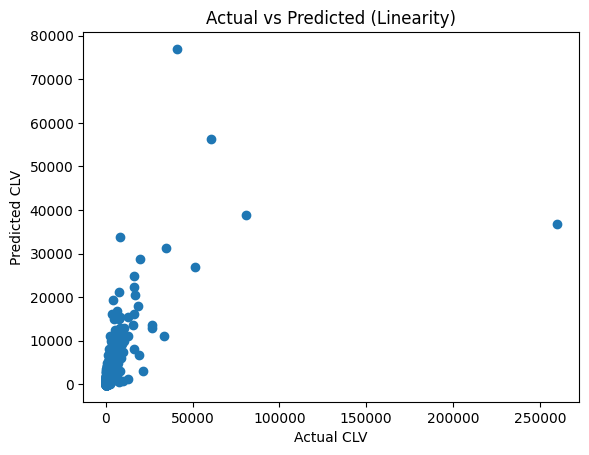

In [46]:

# Linearity (Actual vs Predicted)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted (Linearity)")
plt.show()


In [47]:
#  Residuals
residuals = y_test - y_pred


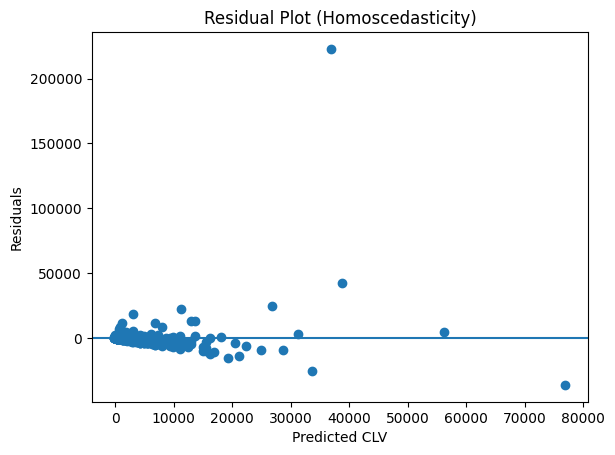

In [48]:
#  Homoscedasticity
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted CLV")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoscedasticity)")
plt.show()


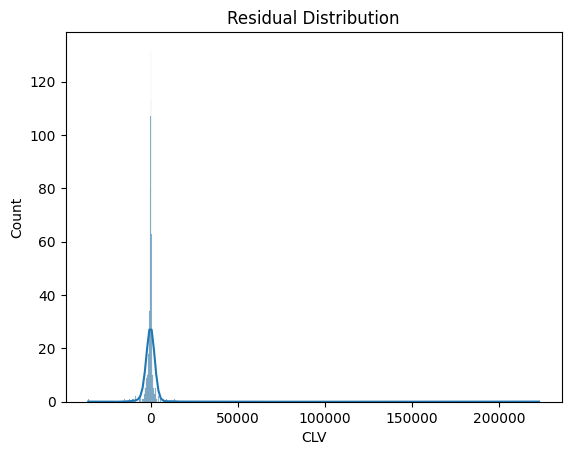

In [49]:
# Normality
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [50]:
# Multicollinearity (VIF)

X_vif = sm.add_constant(X_scaled)

vif_df = pd.DataFrame()
vif_df["Feature"] = ["Intercept", "Recency", "Frequency"]
vif_df["VIF"] = [
    variance_inflation_factor(X_vif, i)
    for i in range(X_vif.shape[1])
]

print("\n========== VIF Values ==========")
print(vif_df)


========== VIF Values ==========
     Feature       VIF
0  Intercept  1.000000
1    Recency  1.072847
2  Frequency  1.072847


 Interpretation

In [51]:
print("\n========== Interpretation ==========")
print("• Lower RMSE & MAE indicate better prediction accuracy.")
print("• R2 closer to 1 indicates a strong model fit.")
print("• Random residual pattern confirms homoscedasticity.")
print("• VIF < 5 means no multicollinearity issue.")


========== Interpretation ==========
• Lower RMSE & MAE indicate better prediction accuracy.
• R2 closer to 1 indicates a strong model fit.
• Random residual pattern confirms homoscedasticity.
• VIF < 5 means no multicollinearity issue.


In [52]:
df.to_csv("online_retail(clean).csv", index=False)

